$ p_{\Delta,ln}(\Delta|\mu_{\rm diff}, \sigma_{ln})=\frac{1}{\sqrt{2\pi}\sigma_{ln}\Delta}\exp[-\frac{(\ln{\Delta-\mu_{ln}})^2}{2\sigma_{ln}^2}] $

Mean value should be $ \exp(\mu+\sigma^2/2)$

Variance should be $ [\exp(\sigma^2)-1]\exp(2\mu +\sigma^2)=\sigma^2(S,z) $

Thus $ \exp(2\mu+\sigma^2)=1$

We have $ [\exp(\sigma_{ln}^2)-1]=\sigma^2(S,z) $

$ \sigma_{ln}^2=ln(\sigma^2(S,z)+1) $

And $ \exp(\mu)=\frac{1}{\sqrt{\sigma^2(S,z)+1}}$

$ \mu=-1/2\ln(\sigma^2(S,z)+1)$

In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


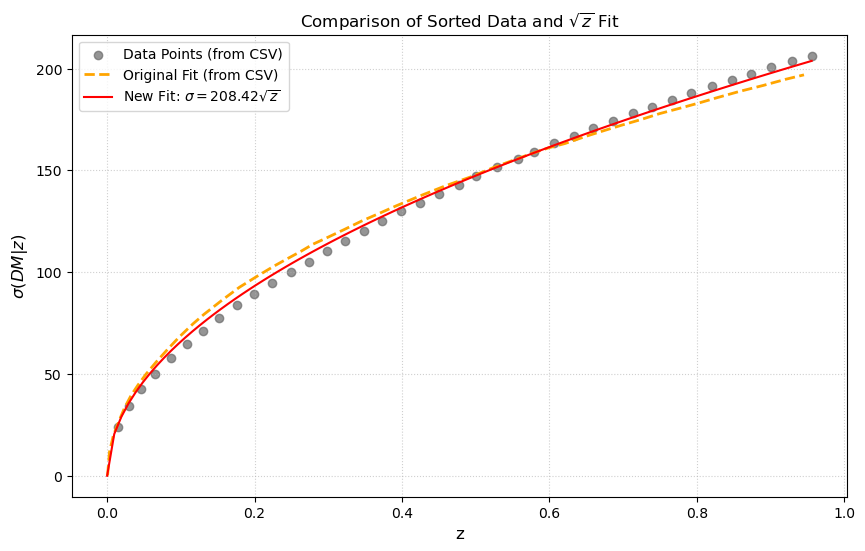

In [2]:
# 1. 加载数据 (跳过第一行 fit/data 标签)
df = pd.read_csv('./Sharma_Astrid.csv', skiprows=1)

# --- 核心修改：分别提取并按照 Z 轴从小到大排序 ---

# 处理 fit 组 (原图中的曲线数据)
fit_subset = df.iloc[:, [0, 1]].dropna()
fit_subset.columns = ['z', 'sigma']
fit_subset = fit_subset.sort_values(by='z') # 排序解决线条折返问题
fit_z = fit_subset['z'].values
fit_sigma = fit_subset['sigma'].values

# 处理 data 组 (你抠出来的散点)
data_subset = df.iloc[:, [2, 3]].dropna()
data_subset.columns = ['z', 'sigma']
data_subset = data_subset.sort_values(by='z') # 排序确保逻辑一致
data_z = data_subset['z'].values
data_sigma = data_subset['sigma'].values

# 2. 定义拟合函数
def sqrt_model(z, a):
    return a * np.sqrt(z)

# 3. 拟合
popt, _ = curve_fit(sqrt_model, data_z, data_sigma, p0=[200])
a_fit = popt[0]

# 4. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# A. 画出原始 Data 点 (散点不受顺序影响，但建议也排序)
plt.scatter(data_z, data_sigma, color='dimgray', alpha=0.7, label='Data Points (from CSV)')

# B. 画出原图自带的 Fit (排序后就变成平滑的虚线了)
plt.plot(fit_z, fit_sigma, color='orange', linestyle='--', linewidth=2, label='Original Fit (from CSV)')

# C. 画出新的 \sqrt{z} 拟合曲线
z_smooth = np.linspace(0, max(data_z.max(), fit_z.max()), 100)
plt.plot(z_smooth, sqrt_model(z_smooth, a_fit), color='red', linewidth=1.5, 
         label=f'New Fit: $\sigma = {a_fit:.2f}\sqrt{{z}}$')

# 修饰
plt.xlabel('z', fontsize=12)
plt.ylabel('$\sigma(DM|z)$', fontsize=12)
plt.title('Comparison of Sorted Data and $\sqrt{z}$ Fit')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

/tmp/ipykernel_8732/1961938749.py:6: RuntimeWarning: invalid value encountered in sqrt
  sigma=np.sqrt(f_variance_delta(S=S, z=z))


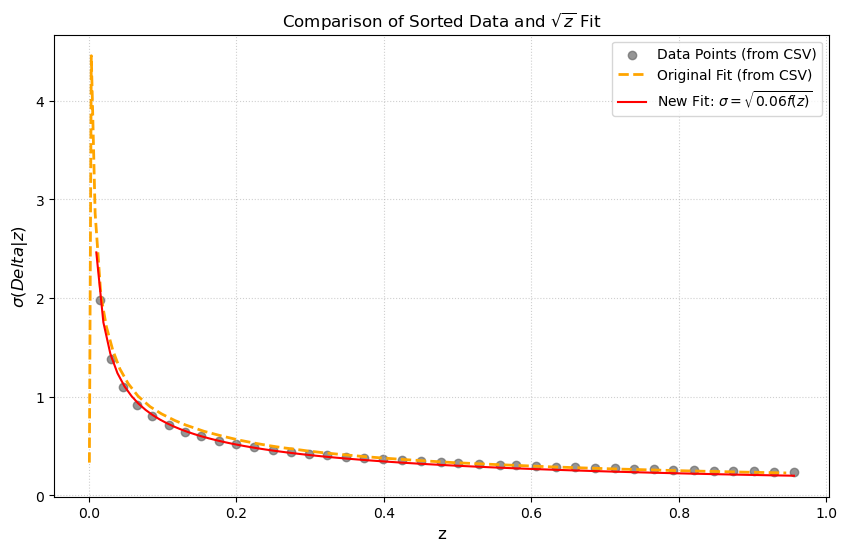

In [4]:
fit_Delta = fit_sigma/dispersion_measure(fit_z)
data_Delta = data_sigma/dispersion_measure(data_z)

# 2. 定义拟合函数
def delta_sqrt(z, S):
    sigma=np.sqrt(f_variance_delta(S=S, z=z))
    return sigma

# 3. 拟合
popt, _ = curve_fit(delta_sqrt, data_z, data_Delta, p0=[200])
S_fit = popt[0]

# 4. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# A. 画出原始 Data 点 (散点不受顺序影响，但建议也排序)
plt.scatter(data_z, data_Delta, color='dimgray', alpha=0.7, label='Data Points (from CSV)')

# B. 画出原图自带的 Fit (排序后就变成平滑的虚线了)
plt.plot(fit_z, fit_Delta, color='orange', linestyle='--', linewidth=2, label='Original Fit (from CSV)')

# C. 画出新的 \sqrt{z} 拟合曲线
z_smooth = np.linspace(0.01, max(data_z.max(), fit_z.max()), 100)
plt.plot(z_smooth, delta_sqrt(z_smooth, S_fit), color='red', linewidth=1.5, 
         label=f'New Fit: $\sigma = \sqrt{{{S_fit:.2f}f(z)}}$')

# 修饰
plt.xlabel('z', fontsize=12)
plt.ylabel('$\sigma(Delta|z)$', fontsize=12)
plt.title('Comparison of Sorted Data and $\sqrt{z}$ Fit')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Thus $\sigma_\Delta=\sigma(S=0.06,z) $